## Setup and Library Installation

In [1]:
# Install necessary libraries
!pip install transformers[torch] datasets scikit-learn matplotlib seaborn

## Load IMDB Dataset (Kaggle Sourcing)

In [18]:
import kagglehub
import os
import pandas as pd
import torch

# Set device globally
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 1. Download dataset from Kaggle
path = kagglehub.dataset_download('vishakhdapat/imdb-movie-reviews')
print('Data downloaded to:', path)

# 2. Identify and Load the CSV file
files = os.listdir(path)
csv_file = [f for f in files if f.endswith('.csv')][0]
df_raw = pd.read_csv(os.path.join(path, csv_file))

print(f"\nRaw Data Loaded. Shape: {df_raw.shape}")
df_raw.head()

Using Colab cache for faster access to the 'imdb-movie-reviews' dataset.
Data downloaded to: /kaggle/input/imdb-movie-reviews

Raw Data Loaded. Shape: (50000, 2)


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


## Data Preprocessing & Splitting

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

# 1. Standardize and Clean
df_prep = df_raw.copy()
df_prep.columns = df_prep.columns.str.lower().str.strip()
df_prep['label'] = df_prep['sentiment'].str.lower().str.strip().map({'positive': 1, 'negative': 0})
df_prep['text'] = df_prep['review'].str.replace('<br />', ' ')
df_prep = df_prep[['text', 'label']].dropna().reset_index(drop=True)

# 2. Create Subset (700 Train, 150 Val, 150 Test)
df_subset = df_prep.sample(1000, random_state=42)
train_df, temp_df = train_test_split(df_subset, train_size=700, random_state=75, stratify=df_subset['label'])
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=75)

print(f"Split complete: Train={len(train_df)}, Val={len(val_df)}, Test={len(test_df)}")

Split complete: Train=700, Val=150, Test=150


## Tokenization & Dataset Class

In [24]:
from torch.utils.data import Dataset
from transformers import BertTokenizer

tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

class IMDBDataset(Dataset):
    def __init__(self, texts, labels):
        self.encodings = tokenizer(texts, padding="max_length", truncation=True, max_length=128)
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

# Create Dataset objects
train_dataset = IMDBDataset(train_df['text'].tolist(), train_df['label'].tolist())
val_dataset = IMDBDataset(val_df['text'].tolist(), val_df['label'].tolist())
test_dataset = IMDBDataset(test_df['text'].tolist(), test_df['label'].tolist())

## Model & Evaluation Helper Functions

In [25]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import DataLoader
from transformers import BertForSequenceClassification, get_linear_schedule_with_warmup
from torch.optim import AdamW
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix

def compute_metrics(eval_pred):
    """Calculates Accuracy, Precision, Recall, and F1."""
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, predictions, average='binary')
    acc = accuracy_score(labels, predictions)
    return {"accuracy": acc, "f1": f1, "precision": precision, "recall": recall}

def run_bert_experiment(model_name, train_ds, val_ds, unfreeze_last_2=False):
    """
    Manual training loop to display text-only progress.
    Avoids 'metadata.widgets' errors on GitHub by using standard print().
    """
    # 1. Initialize Model
    model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=2).to(device)

    # 2. Freezing Logic for Experiments
    if unfreeze_last_2:
        for param in model.bert.parameters():
            param.requires_grad = False
        # Unfreeze exactly the last two encoder layers (10 and 11)
        for i in range(10, 12):
            for param in model.bert.encoder.layer[i].parameters():
                param.requires_grad = True
        print(f"Status: {model_name} - Last 2 Layers Unfrozen.")

    # 3. DataLoaders (Batch Size 5)
    train_loader = DataLoader(train_ds, batch_size=5, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=5)

    # 4. Optimizer & Scheduler (LR = 2e-5)
    optimizer = AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=2e-5)
    epochs = 1
    total_steps = len(train_loader) * epochs
    scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=0, num_training_steps=total_steps)

    print(f'\n{"="*40}\nStarting Experiment: {model_name}\n{"="*40}')

    # 5. Manual Training Loop (Text-based progress)
    for epoch in range(epochs):
        print(f'Epoch {epoch+1}/{epochs}')
        model.train()
        total_train_loss = 0

        for step, batch in enumerate(train_loader):
            # Print text progress every 20 batches (prevents widget creation)
            if step % 20 == 0 and step > 0:
                print(f'    Batch {step:>4} / {len(train_loader)}')

            b_input_ids = batch['input_ids'].to(device)
            b_input_mask = batch['attention_mask'].to(device)
            b_labels = batch['labels'].to(device)

            model.zero_grad()
            outputs = model(b_input_ids, attention_mask=b_input_mask, labels=b_labels)

            loss = outputs.loss
            total_train_loss += loss.item()

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()

        avg_train_loss = total_train_loss / len(train_loader)

        # Validation Phase
        model.eval()
        all_logits, all_labels = [], []
        for batch in val_loader:
            with torch.no_grad():
                outputs = model(batch['input_ids'].to(device),
                                attention_mask=batch['attention_mask'].to(device))
            all_logits.append(outputs.logits.cpu().numpy())
            all_labels.append(batch['labels'].numpy())

        val_metrics = compute_metrics((np.concatenate(all_logits), np.concatenate(all_labels)))
        print(f'Avg Training Loss: {avg_train_loss:.4f} | Val Acc: {val_metrics["accuracy"]:.4f}\n')

    # Compatibility object for plot_results
    class ManualResults:
        def __init__(self, m): self.model = m
        def predict(self, ds):
            self.model.eval()
            loader = DataLoader(ds, batch_size=5)
            preds, labels = [], []
            for b in loader:
                with torch.no_grad():
                    out = self.model(b['input_ids'].to(device), attention_mask=b['attention_mask'].to(device))
                preds.append(out.logits.cpu().numpy())
                labels.append(b['labels'].numpy())
            return type('obj', (object,), {'predictions': np.concatenate(preds), 'label_ids': np.concatenate(labels)})

    return ManualResults(model)

def plot_results(trainer, test_ds, title):
    """Generates side-by-side Metrics Bar Chart and Confusion Matrix."""
    preds_output = trainer.predict(test_ds)
    preds = np.argmax(preds_output.predictions, axis=1)
    labels = preds_output.label_ids

    metrics = compute_metrics((preds_output.predictions, labels))
    acc = metrics['accuracy']

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

    # Metric Bar Chart
    metric_names = ['Accuracy', 'F1-Score', 'Precision', 'Recall']
    metric_values = [metrics['accuracy'], metrics['f1'], metrics['precision'], metrics['recall']]
    sns.barplot(x=metric_names, y=metric_values, palette='viridis', ax=ax1, hue=metric_names, legend=False)
    ax1.set_title(f'{title}: Performance Summary', fontsize=14, fontweight='bold')
    ax1.set_ylim(0, 1.1)

    for i, v in enumerate(metric_values):
        ax1.text(i, v + 0.02, f'{v:.2f}', ha='center', fontweight='bold')

    # Labeled Confusion Matrix
    cm = confusion_matrix(labels, preds)
    group_names = ['True Neg', 'False Pos', 'False Neg', 'True Pos']
    group_counts = ["{0:0.0f}".format(value) for value in cm.flatten()]
    labels_cm = [f"{v1}\n{v2}" for v1, v2 in zip(group_names, group_counts)]
    labels_cm = np.asarray(labels_cm).reshape(2,2)

    sns.heatmap(cm, annot=labels_cm, fmt='', cmap='Blues', ax=ax2, cbar=False,
                xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
    ax2.set_title(f'{title}: Error Distribution', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Predicted'); ax2.set_ylabel('Actual')

    plt.tight_layout()
    plt.show()
    return acc

## Experiment 1 - Full Fine-Tuning


Starting Experiment: Full Fine-Tuning
Epoch 1/1
    Batch   20 / 140
    Batch   40 / 140
    Batch   60 / 140
    Batch   80 / 140
    Batch  100 / 140
    Batch  120 / 140
Avg Training Loss: 0.5819 | Val Acc: 0.7933



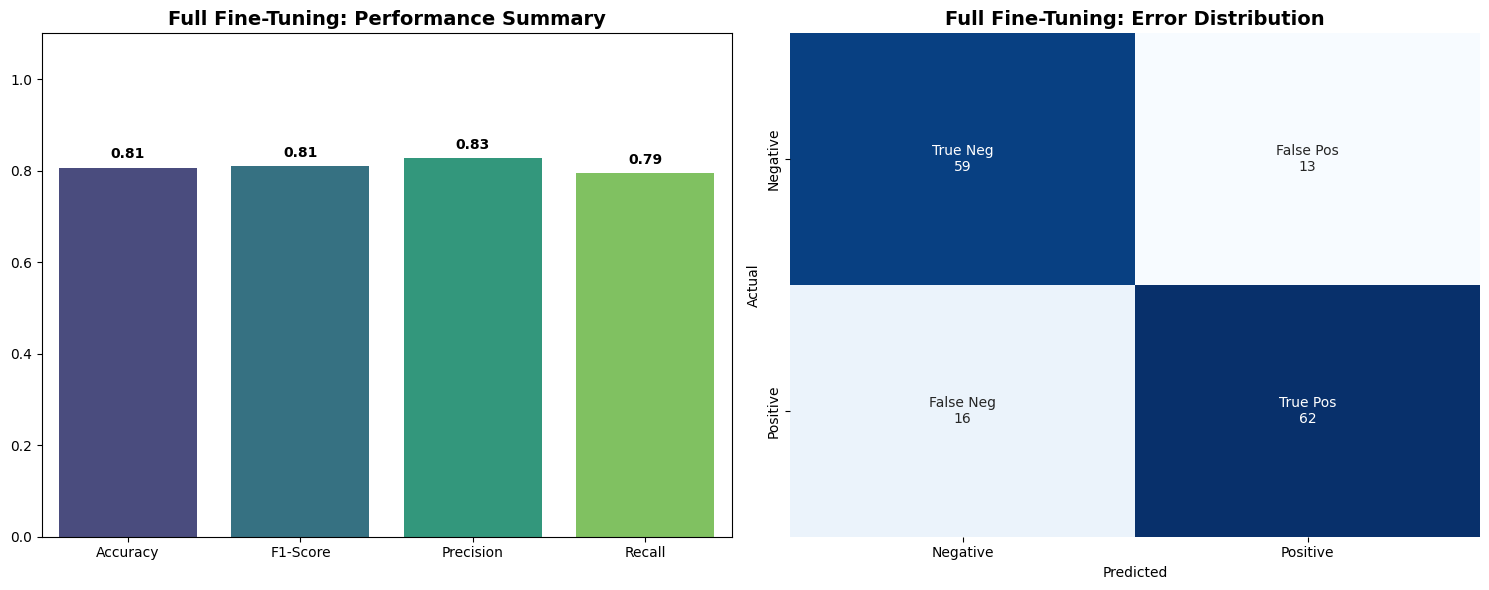

In [26]:
# Train full model
results_full = run_bert_experiment("Full Fine-Tuning", train_dataset, val_dataset, unfreeze_last_2=False)

# Evaluate and visualize
acc_full = plot_results(results_full, test_dataset, "Full Fine-Tuning")

## Experiment 2 - Freezing BERT Layers

Status: Last 2 Layers Unfrozen - Last 2 Layers Unfrozen.

Starting Experiment: Last 2 Layers Unfrozen
Epoch 1/1
    Batch   20 / 140
    Batch   40 / 140
    Batch   60 / 140
    Batch   80 / 140
    Batch  100 / 140
    Batch  120 / 140
Avg Training Loss: 0.6395 | Val Acc: 0.6867



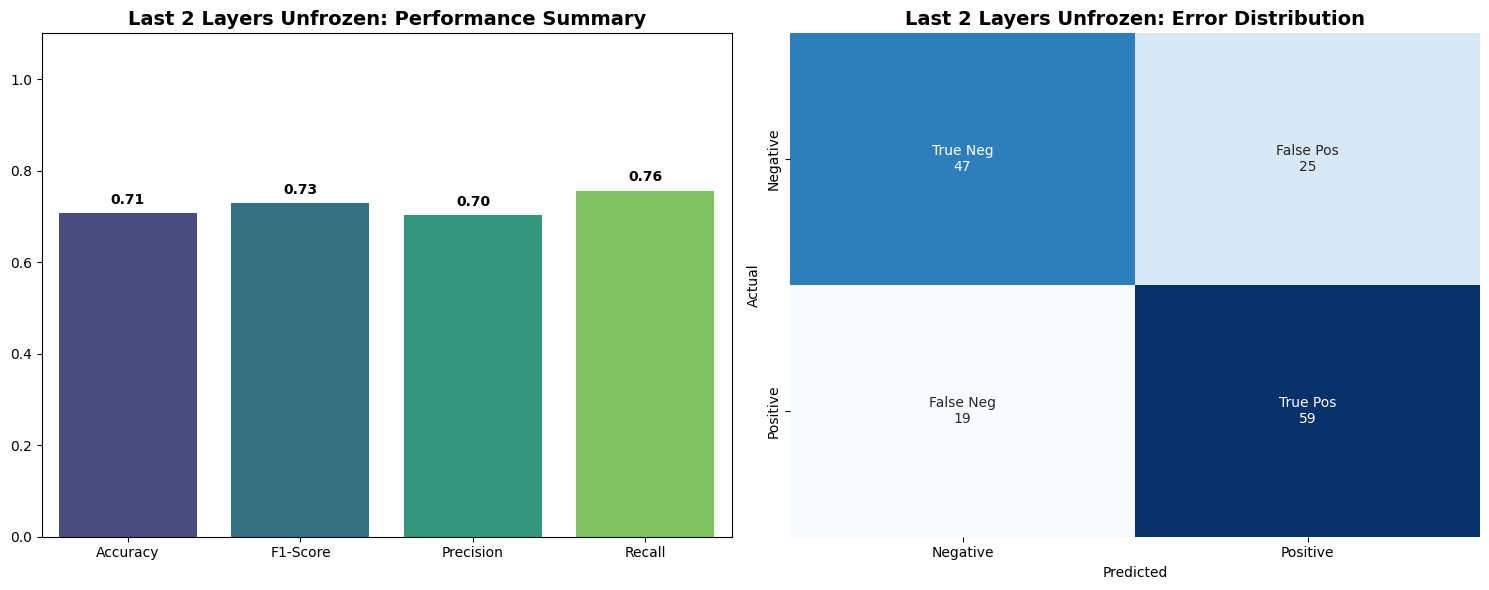

In [27]:
# Train partial model
results_last2 = run_bert_experiment("Last 2 Layers Unfrozen", train_dataset, val_dataset, unfreeze_last_2=True)

# Evaluate and visualize
acc_last2 = plot_results(results_last2, test_dataset, "Last 2 Layers Unfrozen")

## Visualizing Performance (Graphs)

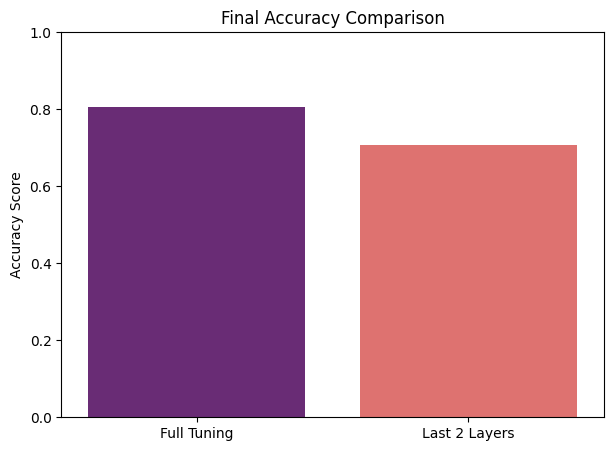

In [28]:
# Final comparison bar chart
methods = ['Full Tuning', 'Last 2 Layers']
accuracies = [acc_full, acc_last2]

plt.figure(figsize=(7, 5))
sns.barplot(x=methods, y=accuracies, palette='magma')
plt.title('Final Accuracy Comparison')
plt.ylabel('Accuracy Score')
plt.ylim(0, 1)
plt.show()